In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import SCF as scf

SCF module has been imported.


In [3]:
NWS = [25,50,75]

1.0
2.0
3.0


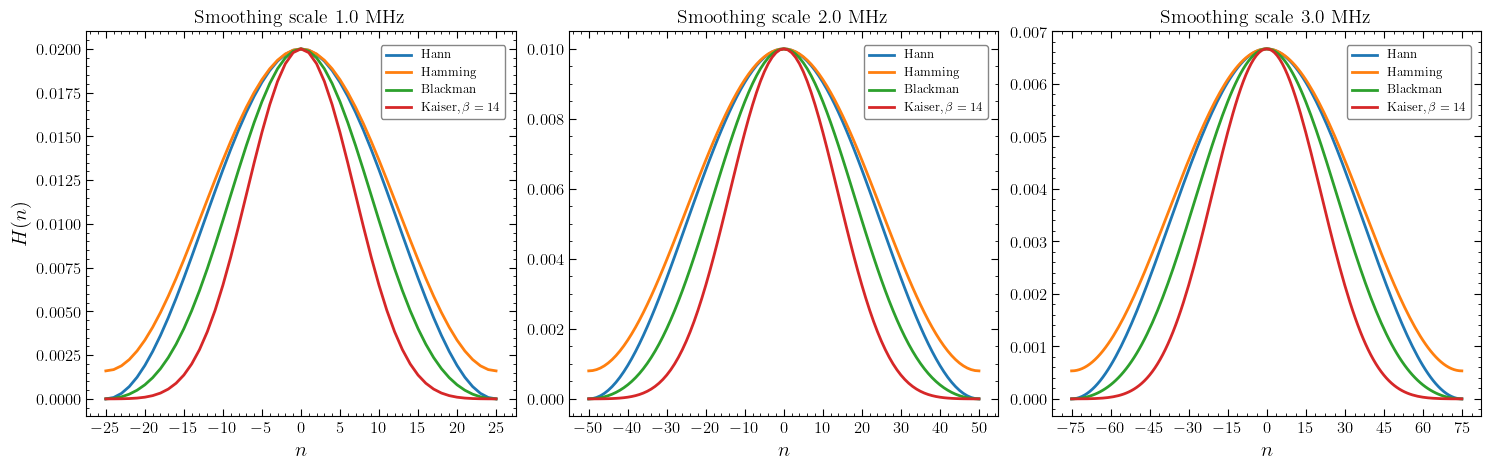

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (18,5))

ax[0].set_ylabel(rf'$H(n)$')

jj = 0
for NW in NWS:
    NN = 2*NW+1
    SM = 0.04*NW
    print(SM)

    ax[jj].plot(np.arange(-NW,NW+1), np.hanning(NN)/(2*NW), label = "Hann")
    ax[jj].plot(np.arange(-NW,NW+1), np.hamming(NN)/(2*NW), label = "Hamming")
    ax[jj].plot(np.arange(-NW,NW+1), np.blackman(NN)/(2*NW), label = "Blackman")
    ax[jj].plot(np.arange(-NW,NW+1), np.kaiser(NN,14)/(2*NW), label = r"Kaiser,\,$\beta=14$")

    ax[jj].set_xticks(np.arange(-NW,NW+NW/5,NW/5))

    ax[jj].set_xlabel(rf'$n$')
    
    ax[jj].set_title(rf"Smoothing scale {SM} MHz ", fontsize = 14)


    ax[jj].legend(
    loc = "upper right",           # change position here
    bbox_to_anchor = (0.99, 0.98), # bottom left is (0,0) and top right is (1,1)
    facecolor = "white",           # Background color of the legend box
    edgecolor = "gray",            # Color of the border around the legend
    framealpha = 0.95,             # Transparency of the legend box (1 = fully opaque)
    fancybox = True,               # Enables rounded corners on the legend box
    frameon = True,                # Shows the legend frame (the box itself)
    fontsize = 9                   # Font size of the legend text
    )

    jj+=1

plt.subplots_adjust( wspace = 0.125)
plt.savefig(f"windows_123.pdf", dpi = 700, bbox_inches = "tight", pad_inches = 0.04)
plt.show()

1.0


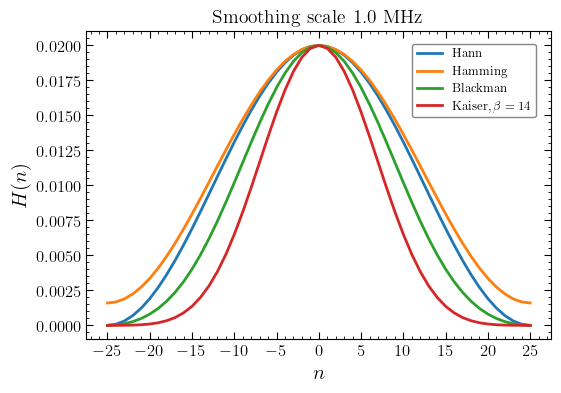

2.0


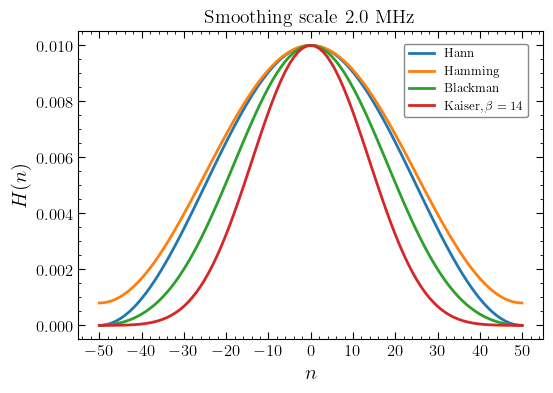

3.0


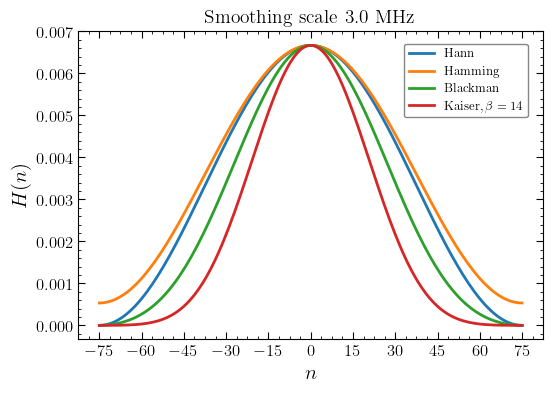

In [5]:
for NW in NWS:
    NN = 2*NW+1
    SM = 0.04*NW
    print(SM)

    fig = plt.figure(figsize = (6,4))
    plt.plot(np.arange(-NW,NW+1), np.hanning(NN)/(2*NW), label = "Hann")
    plt.plot(np.arange(-NW,NW+1), np.hamming(NN)/(2*NW), label = "Hamming")
    plt.plot(np.arange(-NW,NW+1), np.blackman(NN)/(2*NW), label = "Blackman")
    plt.plot(np.arange(-NW,NW+1), np.kaiser(NN,14)/(2*NW), label = r"Kaiser,\,$\beta=14$")
    
    plt.xticks(np.arange(-NW,NW+NW/5,NW/5))
    
    plt.xlabel(rf'$n$')
    plt.ylabel(rf'$H(n)$')
    
    
    plt.legend(
        loc = "upper right",           # change position here
        bbox_to_anchor = (0.98, 0.98), # bottom left is (0,0) and top right is (1,1)
        facecolor = "white",           # Background color of the legend box
        edgecolor = "gray",            # Color of the border around the legend
        framealpha = 0.95,             # Transparency of the legend box (1 = fully opaque)
        fancybox = True,               # Enables rounded corners on the legend box
        frameon = True,                # Shows the legend frame (the box itself)
        fontsize = 9                   # Font size of the legend text
    )
    
    plt.title(rf"Smoothing scale {SM} MHz ", fontsize = 14)
    plt.savefig(f"windows_{SM}.pdf", dpi = 700, bbox_inches = "tight", pad_inches = 0.04)
    plt.show()

In [6]:
GV = np.load("GV_7560.npy")

In [7]:
SM = 2
NW  = int(SM/scf.dnuc)   # N # = 50 if SM = 2 MHz and dnuc = 0.04 MHz
NN  = 2*NW + 1       # total width (2N+1)
print(NN)
window = 'hann'

101


In [8]:
GV_filtered = scf.doscf(GV, SM, window = window, method = 'fft')


<======================= Performing SCF =======================>
<=== Start Time: Thursday, 25 December 2025 | 06:28:26 PM   ===>

Convolution kernel : fft
Window function    : Hanning
Smoothing scale    : 2 MHz

<=== End Time  : Thursday, 25 December 2025 | 06:28:33 PM   ===>
<=== Elapsed   : 00:00:07.58 , 7.583 seconds                ===>
<=======================    Done SCF    =======================>



In [9]:
dnuc = 0.04
nc = GV.shape[-1]

In [10]:
NN = int(SM/dnuc)
nc1 = nc - 2*NN
print(dnuc,nc,NN,nc1)

0.04 768 50 668


In [11]:
print(GV.shape)

(2, 457, 457, 768)


In [12]:
mask = np.zeros(nc)
mask[scf.flag_indices] = 1
mask.shape

(768,)

In [13]:
nua = 154.255+(np.arange(nc)-384+1)*0.04

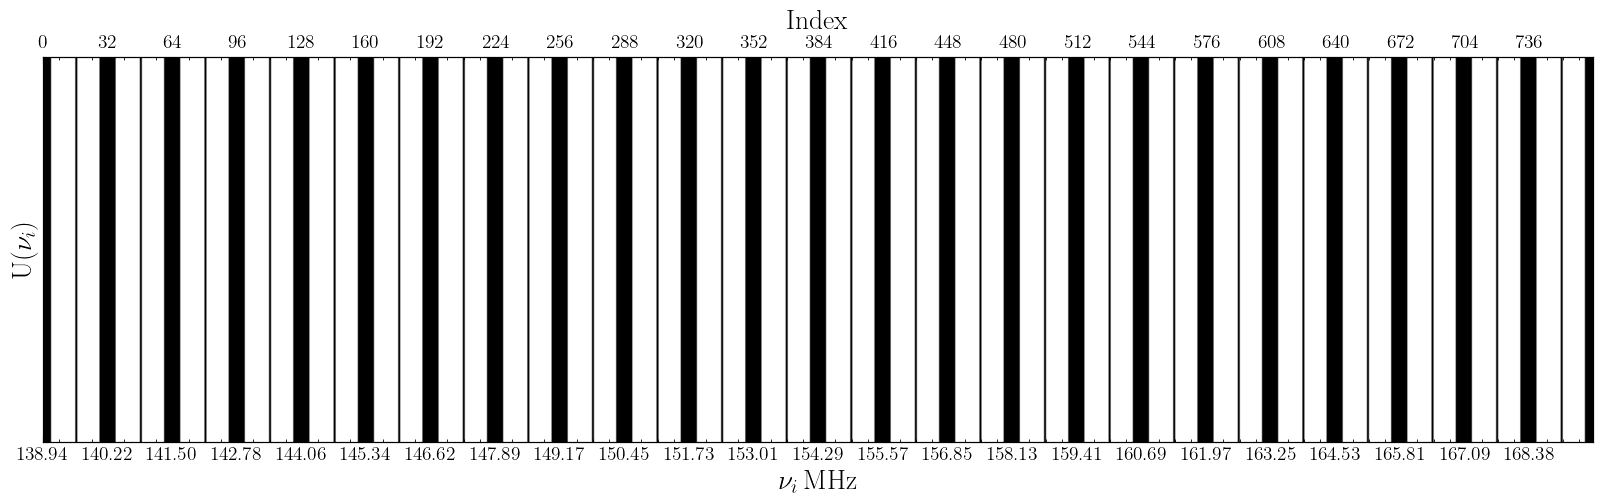

In [14]:
fig, ax = plt.subplots(figsize = (20,5))

ax.imshow(mask[None,:], extent = [nua[0],nua[-1],-1,1], aspect = 'auto', cmap = 'binary')

ax.set_xticks(nua[np.arange(0,768,32)])

ax.tick_params(axis = 'x', labelsize = 14)


ax.set_xlabel(r'$\nu_i\,{\rm MHz}$', fontsize = 20)
ax.set_ylabel(r'${\rm U}(\nu_i)$', fontsize = 20)
ax.set_yticks([])

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())  # align axes
ax_top.set_xticks(nua[np.arange(0,768,32)])
ax_top.set_xticklabels(np.arange(0,768,32))
ax_top.set_xlabel("Index", fontsize = 20)
ax_top.tick_params(axis = 'x', labelsize = 14)

plt.savefig(f"Flag.png", dpi = 700, bbox_inches = "tight", pad_inches = 0.04)
plt.savefig(f"Flag.pdf", dpi = 700, bbox_inches = "tight", pad_inches = 0.04)

plt.show()

In [15]:
mask = mask[NN:-NN]
nua = nua[NN:-NN]
mask.shape

(668,)

In [16]:
center = GV.shape[1]//2
print(center)

228


In [17]:
ii = 221
jj = 269
U = np.sqrt((ii-center)**2+(jj-center)**2)
l = (2*np.pi*U).astype('int')
print(f"{l = }")

l = np.int64(261)


In [18]:
a = np.ma.array(GV[0,ii,jj,NN:-NN].real,mask = mask) #XX
b = np.ma.array(GV[1,ii,jj,NN:-NN].real,mask = mask) #YY

In [19]:
c = np.ma.array(GV_filtered[0,ii,jj].real,mask = mask) #XX
d = np.ma.array(GV_filtered[1,ii,jj].real,mask = mask) #YY

In [20]:
e = np.ma.array(GV[0,ii,jj,NN:-NN].real - GV_filtered[0,ii,jj].real,mask = mask) #XX
f = np.ma.array(GV[1,ii,jj,NN:-NN].real - GV_filtered[1,ii,jj].real,mask = mask) #YY

In [21]:
a.shape, b.shape , c.shape , d.shape , e.shape , f.shape

((668,), (668,), (668,), (668,), (668,), (668,))

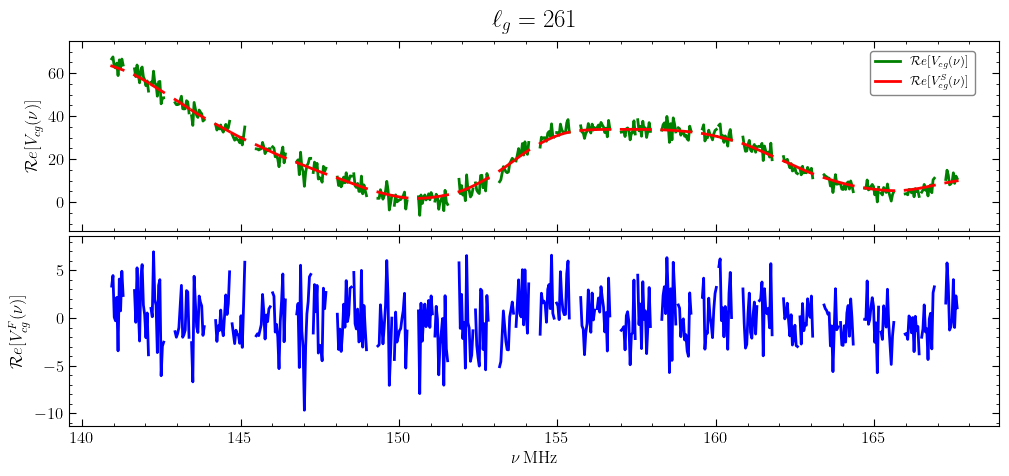

In [22]:
fig , ax  = plt.subplots(nrows = 2, ncols = 1, sharex = True, figsize = (12,5))

ax[0].plot(nua, a, 'g',label = r'$\mathcal{R}e[V_{cg}(\nu)]$')
ax[0].plot(nua, e, 'r',label = r'$\mathcal{R}e[V_{cg}^S(\nu)]$')


ax[0].legend(fontsize = 12)
ax[0].set_title(rf'$\ell_g = {l}$',pad = 10)
ax[1].set_xlabel(r'$\nu\, {\rm MHz}$',fontsize = 12)
ax[0].set_ylabel(r'$\mathcal{R}e[V_{cg}(\nu)]$',fontsize = 12)
ax[1].set_ylabel(r'$\mathcal{R}e[V_{cg}^F(\nu)]$',fontsize = 12)

ax[1].plot(nua,c,'b')


ax[0].margins(x = .05, y = 0.1)
ax[1].margins(x = .05, y = 0.1)

plt.subplots_adjust(hspace=0.025)



ax[0].legend(
        loc = "upper right",           # change position here
        bbox_to_anchor = (0.98, 0.98), # bottom left is (0,0) and top right is (1,1)
        facecolor = "white",           # Background color of the legend box
        edgecolor = "gray",            # Color of the border around the legend
        framealpha = 0.95,             # Transparency of the legend box (1 = fully opaque)
        fancybox = True,               # Enables rounded corners on the legend box
        frameon = True,                # Shows the legend frame (the box itself)
        fontsize = 9                   # Font size of the legend text
    )

plt.savefig(f"scf.pdf", dpi = 700, bbox_inches = "tight", pad_inches = 0.04)
plt.show()